<a href="https://colab.research.google.com/github/fighaz/btc-price-prediction/blob/main/BTCIDR_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
import pandas as pd

url = "https://indodax.com/tradingview/history_v2"

params = {
    "from": 1391191321,   # timestamp awal
    "to": 1753920000,     # timestamp akhir
    "symbol": "BTCIDR",   # pair yang diambil
    "tf": "1D"            # timeframe 1 hari
}

response = requests.get(url, params=params)

if response.status_code == 200:
    data = response.json()
    df = pd.DataFrame(data)

    # Convert UNIX timestamp -> datetime
    df["Time"] = pd.to_datetime(df["Time"], unit="s")

    df["Open"] = df["Open"].astype(float)
    df["High"] = df["High"].astype(float)
    df["Low"] = df["Low"].astype(float)
    df["Close"] = df["Close"].astype(float)
    df["Volume"] = df["Volume"].astype(float)

    print(df.head())
else:
    print("Gagal fetch data:", response.status_code)


        Time       Open        High        Low      Close     Volume
0 2014-02-09  8677650.0   8757600.0  8562558.0  8597540.0  10.149997
1 2014-02-10  8585400.0   8853540.0  6519000.0  8290827.0  49.209952
2 2014-02-11  8290200.0   8697365.0  7693000.0  8142036.0  32.590180
3 2014-02-12  8097274.0  10000000.0  7822347.0  8023750.0   6.940986
4 2014-02-13  7749068.0   7857150.0  7175670.0  7239750.0   7.156985


In [ ]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4191 entries, 0 to 4190
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Time    4191 non-null   datetime64[ns]
 1   Open    4191 non-null   float64       
 2   High    4191 non-null   float64       
 3   Low     4191 non-null   float64       
 4   Close   4191 non-null   float64       
 5   Volume  4191 non-null   float64       
 6   EMA20   4191 non-null   float64       
 7   EMA50   4191 non-null   float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 262.1 KB


,Time,Open,High,Low,Close,Volume,EMA20,EMA50
count,4191,4.191000e+03,4.191000e+03,4.191000e+03,4.191000e+03,4191.000000,4.191000e+03,4.191000e+03
mean,2019-11-04 23:59:59.999999744,3.469087e+08,3.532778e+08,3.400146e+08,3.473503e+08,277.982205,3.430432e+08,3.366427e+08
min,2014-02-09 00:00:00,2.305000e+06,2.669000e+06,2.006000e+06,2.299000e+06,0.000000,2.856673e+06,3.063372e+06
25%,2016-12-22 12:00:00,1.069730e+07,1.107395e+07,1.056485e+07,1.083840e+07,43.687922,1.066993e+07,1.011206e+07
50%,2019-11-05 00:00:00,1.335020e+08,1.349900e+08,1.320990e+08,1.335230e+08,147.113468,1.335675e+08,1.318268e+08
75%,2022-09-17 12:00:00,5.360245e+08,5.510395e+08,5.150660e+08,5.360855e+08,352.334913,5.291460e+08,5.332068e+08
max,2025-07-31 00:00:00,1.945019e+09,1.985849e+09,1.931000e+09,1.945349e+09,4977.542685,1.908681e+09,1.840250e+09
std,NaN,4.448402e+08,4.517706e+08,4.371605e+08,4.454442e+08,395.530919,4.381513e+08,4.273147e+08


In [ ]:
from google.colab import data_table
data_table.enable_dataframe_formatter()

df

,Time,Open,High,Low,Close,Volume,EMA20,EMA50
0,2014-02-09,8.677650e+06,8.757600e+06,8.562558e+06,8.597540e+06,10.149997,8.597540e+06,8.597540e+06
1,2014-02-10,8.585400e+06,8.853540e+06,6.519000e+06,8.290827e+06,49.209952,8.568329e+06,8.585512e+06
2,2014-02-11,8.290200e+06,8.697365e+06,7.693000e+06,8.142036e+06,32.590180,8.527730e+06,8.568121e+06
3,2014-02-12,8.097274e+06,1.000000e+07,7.822347e+06,8.023750e+06,6.940986,8.479732e+06,8.546773e+06
4,2014-02-13,7.749068e+06,7.857150e+06,7.175670e+06,7.239750e+06,7.156985,8.361638e+06,8.495517e+06
...,...,...,...,...,...,...,...,...
4186,2025-07-27,1.925868e+09,1.940975e+09,1.918874e+09,1.940600e+09,19.979163,1.896362e+09,1.823960e+09
4187,2025-07-28,1.940600e+09,1.945000e+09,1.923000e+09,1.938999e+09,31.639029,1.900423e+09,1.828471e+09
4188,2025-07-29,1.938999e+09,1.950000e+09,1.931000e+09,1.938161e+09,28.790981,1.904017e+09,1.832773e+09
4189,2025-07-30,1.938161e+09,1.948996e+09,1.920005e+09,1.939950e+09,24.501603,1.907439e+09,1.836976e+09


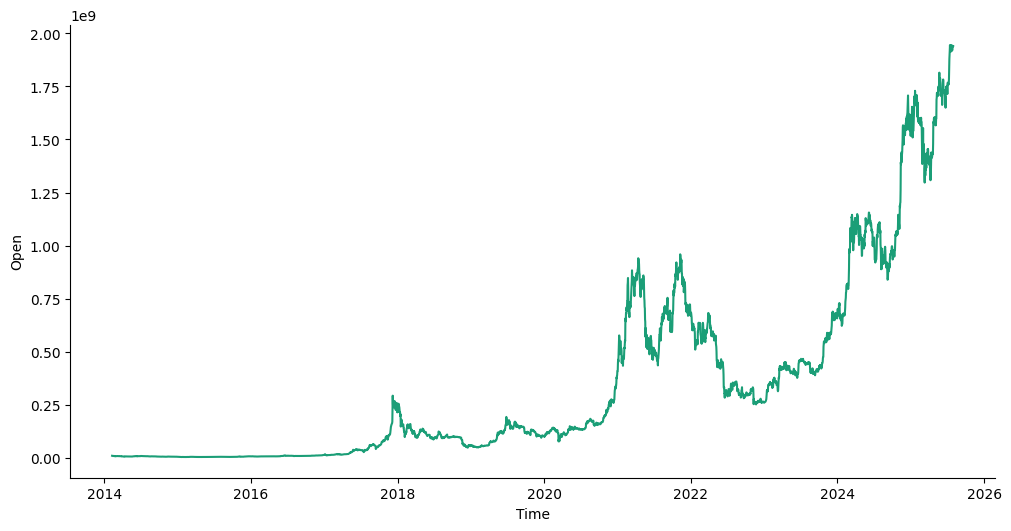

In [ ]:

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Time']
  ys = series['Open']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df.sort_values('Time', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Time')
_ = plt.ylabel('Open')

In [ ]:
df.set_index("Time", inplace=True)

# Resample per bulan dan ambil nilai Low terendah
monthly_low = df["Low"].resample("M").min().reset_index()

print(monthly_low.head())

        Time        Low
0 2014-02-28  5500000.0
1 2014-03-31  5114000.0
2 2014-04-30  4200000.0
3 2014-05-31  4818000.0
4 2014-06-30  6000000.0


In [ ]:
if "Time" not in df.columns:
    df = df.reset_index().rename(columns={"index": "Time"})

df = df.sort_values("Time").reset_index(drop=True)

# Hitung EMA
df["EMA20"] = df["Close"].ewm(span=20, adjust=False).mean()
df["EMA50"] = df["Close"].ewm(span=50, adjust=False).mean()




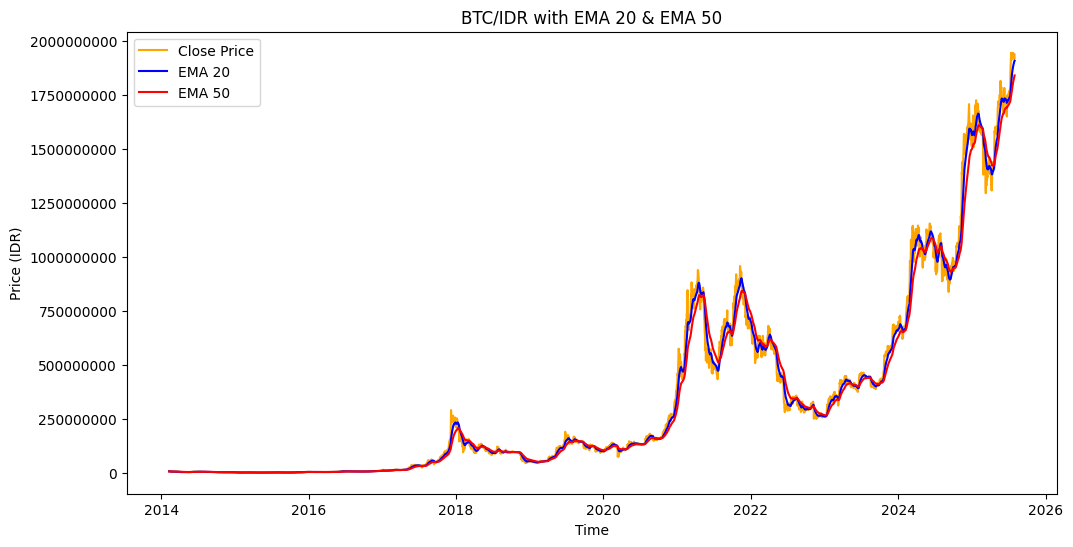

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(12,6))
plt.plot(df["Time"], df["Close"], label="Close Price", color="orange")
plt.plot(df["Time"], df["EMA20"], label="EMA 20", color="blue")
plt.plot(df["Time"], df["EMA50"], label="EMA 50", color="red")

plt.title("BTC/IDR with EMA 20 & EMA 50")
plt.xlabel("Time")
plt.ylabel("Price (IDR)")

ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.ScalarFormatter(useOffset=False))
ax.ticklabel_format(style="plain", axis="y")

plt.legend()
plt.show()


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.0090 - val_loss: 0.0964
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0088 - val_loss: 0.0862
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0069 - val_loss: 0.0684
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0046 - val_loss: 0.0396
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0057 - val_loss: 0.0376
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0050 - val_loss: 0.0614
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0042 - val_loss: 0.0460
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0042 - val_loss: 0.0605
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0033 - val_loss: 0.0429
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0035 - val_loss: 0.0409
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0035 - val_loss: 0.0368
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0035 - val_loss: 0.0252
E

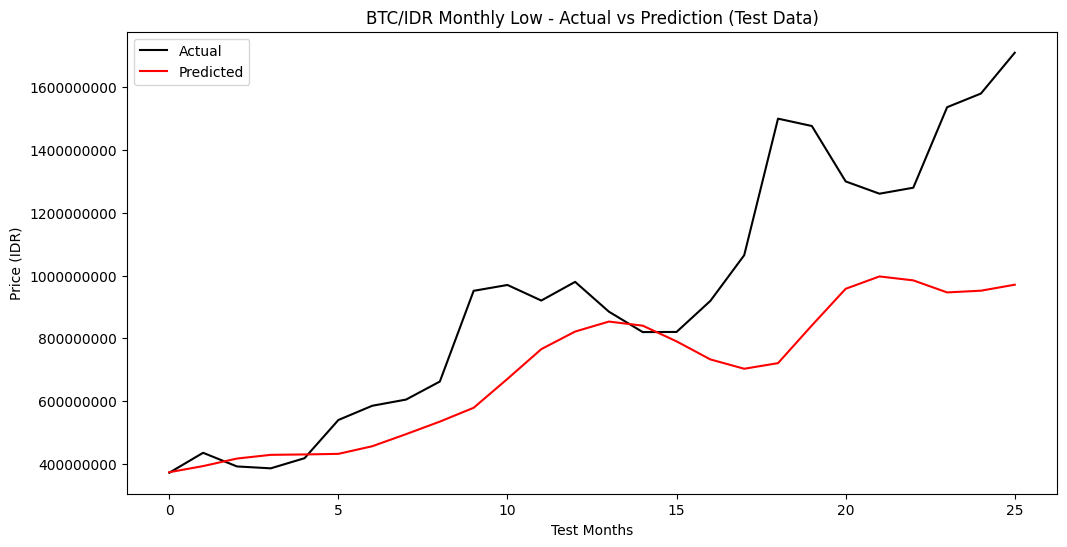

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# buat monthly_low
df.set_index("Time", inplace=True)
monthly_low = df["Low"].resample("M").min().reset_index()

# Normalisasi data
scaler = MinMaxScaler()
monthly_low["Low_scaled"] = scaler.fit_transform(monthly_low[["Low"]])

# dataset sequence untuk LSTM
def create_sequences(data, seq_length=12):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

SEQ_LEN = 12
X, y = create_sequences(monthly_low["Low_scaled"].values, SEQ_LEN)

# reshape ke format LSTM
X = X.reshape((X.shape[0], X.shape[1], 1))


split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Model LSTM
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
history = model.fit(X_train, y_train, epochs=50, batch_size=16,
                    validation_data=(X_test, y_test), verbose=1)

y_pred = model.predict(X_test)

# Inverse transform
y_test_real = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
y_pred_real = scaler.inverse_transform(y_pred).flatten()

# Prediksi bulan Juli 2025
last_sequence = monthly_low["Low_scaled"].values[-SEQ_LEN:]
last_sequence = last_sequence.reshape((1, SEQ_LEN, 1))
july_pred_scaled = model.predict(last_sequence)
july_pred_real = scaler.inverse_transform(july_pred_scaled)[0,0]

print(f"📌 Prediksi Low bulan Juli 2025: {july_pred_real:,.0f} IDR")

# Cari actual Juli 2025
actual_july = monthly_low[monthly_low["Time"].dt.to_period("M") == "2025-07"]["Low"].values
if len(actual_july) > 0:
    print(f"✅ Actual Low Juli 2025: {actual_july[0]:,.0f} IDR")


plt.figure(figsize=(12,6))
plt.plot(y_test_real, label="Actual", color="black")
plt.plot(y_pred_real, label="Predicted", color="red")
plt.title("BTC/IDR Monthly Low - Actual vs Prediction (Test Data)")
plt.xlabel("Test Months")
plt.ylabel("Price (IDR)")

ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.ScalarFormatter(useOffset=False))
ax.ticklabel_format(style="plain", axis="y")

plt.legend()
plt.show()
